# FD004 stress test

Everything so far ran on FD001: one operating condition, one fault mode -- the
easy C-MAPSS subset. FD004 has **six operating conditions and two fault modes**,
and it is the standard stress test in the C-MAPSS literature for exactly that
reason.

The question this notebook asks: does the 02 pipeline, ported as-is, still
work? And if it breaks, why, and what is the smallest fix?

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import sys
sys.path.append('..')  # so `import src` resolves from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

column_names = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor{i}' for i in range(1, 22)]
train = pd.read_csv('../data/train_FD004.txt', sep=r'\s+', header=None, names=column_names)
test = pd.read_csv('../data/test_FD004.txt', sep=r'\s+', header=None, names=column_names)
rul_true = pd.read_csv('../data/RUL_FD004.txt', sep=r'\s+', header=None, names=['RUL'])['RUL'].values

print("Train:", train.shape, "|", train['unit'].nunique(), "engines")
print("Test: ", test.shape, "|", test['unit'].nunique(), "engines")

Train: (61249, 26) | 249 engines
Test:  (41214, 26) | 248 engines


## Why FD001's "constant sensors" aren't constant here

01's EDA found 7 sensors with zero variance across the whole FD001 dataset and
dropped them as uninformative. That reasoning assumed one operating condition --
under a single regime, a flat sensor really is flat.

FD004 has six operating regimes, and several sensors have a different baseline
in each one. A sensor that looks like it's "moving" across the dataset may
just be tracking which regime the engine happens to be in, with degradation
buried underneath.

In [2]:
fd001_constant = ['sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
sensor_cols = [f'sensor{i}' for i in range(1, 22)]

comparison = pd.DataFrame({
    'std_overall': train[sensor_cols].std(),
    'was_constant_in_FD001': [c in fd001_constant for c in sensor_cols],
})
comparison.sort_values('std_overall')

,std_overall,was_constant_in_FD001
sensor16,0.004685,True
sensor10,0.127681,True
sensor15,0.750374,False
sensor11,3.243492,False
sensor5,3.622872,True
sensor19,5.369424,True
sensor6,5.444017,True
sensor21,5.962697,False
sensor20,9.936396,False
sensor1,26.436832,True


In [3]:
# Every sensor FD001 called constant has real variance here -- except sensor16,
# which stays flat regardless of operating condition and is the only one worth
# dropping outright. The rest are informative, but confounded with regime.
near_constant = [c for c in sensor_cols if train[c].std() < 0.01]
sensors = [c for c in sensor_cols if c not in near_constant]

print("Dropped as genuinely constant:", near_constant)
print("Kept:", len(sensors), "sensors")

Dropped as genuinely constant: ['sensor16']
Kept: 20 sensors


Distinct (op1, op2, op3) combinations: 6


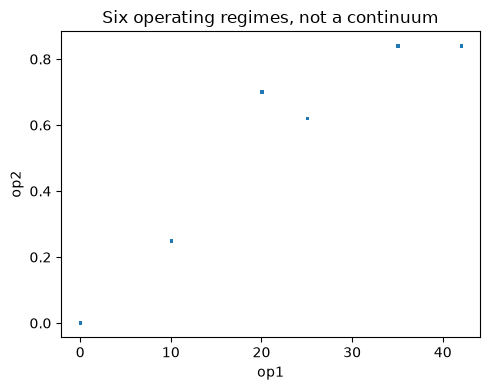

In [4]:
# op1-3 combinations cluster into six tight groups rather than varying
# continuously -- the simulator runs a fixed flight profile, not random settings.
# round(1) leaves two near-duplicate rows from floating-point noise around
# the same set point (op2 = 0.2 vs 0.3 at op1 = 10); round(0) collapses them.
op_combinations = train[['op1', 'op2', 'op3']].round(0).drop_duplicates()
print("Distinct (op1, op2, op3) combinations:", len(op_combinations))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(train['op1'], train['op2'], s=1, alpha=0.1)
ax.set_xlabel('op1'); ax.set_ylabel('op2')
ax.set_title('Six operating regimes, not a continuum')
plt.tight_layout(); plt.show()

## RUL labeling and split

Same logic as 02: RUL is cycles-to-failure, capped at 125 (weak degradation
signal before that point, and it keeps this comparable to the FD001 numbers).
Split is engine-wise, same seed convention, just a different holdout count
since there are 249 engines here instead of 100.

In [5]:
max_cycle = train.groupby('unit')['cycle'].max().rename('max_cycle')
train = train.merge(max_cycle, on='unit')
RUL_CAP = 125
train['RUL'] = (train['max_cycle'] - train['cycle']).clip(upper=RUL_CAP)

np.random.seed(42)
unique_engines = train['unit'].unique()
np.random.shuffle(unique_engines)
n_val_engines = 50                      # roughly the same 20% split as FD001
val_engines = unique_engines[:n_val_engines]
train_engines = unique_engines[n_val_engines:]

train_split = train[train['unit'].isin(train_engines)].copy()
val_split = train[train['unit'].isin(val_engines)].copy()

print("Train engines:", train_split['unit'].nunique(), "| rows:", len(train_split))
print("Val engines:  ", val_split['unit'].nunique(), "| rows:", len(val_split))
assert set(train_split['unit']) & set(val_split['unit']) == set(), "leakage!"

Train engines: 199 | rows: 49294
Val engines:   50 | rows: 11955


In [6]:
from src.evaluation import nasa_score
from src.sequences import create_sequences
from src.lstm_model import LSTMRegressor, train_lstm

SEQ_LENGTH = 30

## Scenario A: port the FD001 pipeline as-is

Standardize every sensor over the whole dataset, ignoring operating condition
entirely -- exactly what 02 did for FD001, where it was safe because there was
only one condition to begin with.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_naive = StandardScaler().fit(train_split[sensors])
train_split_a = train_split.copy()
train_split_a[sensors] = scaler_naive.transform(train_split[sensors])
val_split_a = val_split.copy()
val_split_a[sensors] = scaler_naive.transform(val_split[sensors])

X_train_a, y_train_a = create_sequences(train_split_a, sensors)
X_val_a, y_val_a = create_sequences(val_split_a, sensors)
print("Sequences:", X_train_a.shape, X_val_a.shape)

model_a, pred_a, _ = train_lstm(X_train_a, y_train_a, X_val_a, y_val_a, epochs=25)
rmse_a = np.sqrt(mean_squared_error(y_val_a, pred_a))
score_a = nasa_score(y_val_a, pred_a)
print(f"\nScenario A (naive)  val RMSE: {rmse_a:.2f}   NASA score: {score_a:.0f}")

Sequences:

 (43523, 30, 20) (10505, 30, 20)



Scenario A (naive)  val RMSE: 26.57   NASA score: 171067


## Scenario B: normalize within operating condition

Cluster `(op1, op2, op3)` into six groups with k-means -- the plot above shows
they are already tight, well-separated clusters, so this is closer to labeling
than to modeling. Then z-score every sensor **within its own cluster**, using
statistics from the training split only.

This is the standard C-MAPSS fix for FD002/FD004: it removes the operating-point
offset and leaves only the degradation trend, which is what the earlier
within-cluster std check (0.48 vs 37.3 for sensor2) already confirmed.

In [8]:
# Fit the clustering on training engines only. The regimes are separable
# enough that including validation rows barely moves the centroids, but
# fitting on data the model is later scored against is leakage regardless
# of how small the effect is -- same discipline as the scaler in 02.
op_cluster_model = KMeans(n_clusters=6, random_state=42, n_init=10).fit(
    train[train['unit'].isin(train_engines)][['op1', 'op2', 'op3']]
)
train['op_cluster'] = op_cluster_model.predict(train[['op1', 'op2', 'op3']])

train_split_b = train[train['unit'].isin(train_engines)].copy()
val_split_b = train[train['unit'].isin(val_engines)].copy()

# Per-cluster mean/std from the training split only -- the same "fit on train,
# transform everywhere" discipline as StandardScaler in 02.
cluster_stats = train_split_b.groupby('op_cluster')[sensors].agg(['mean', 'std'])


def normalize_by_cluster(df, stats, sensor_cols):
    out = df.copy()
    out[sensor_cols] = out[sensor_cols].astype(float)
    for cl in df['op_cluster'].unique():
        mask = out['op_cluster'] == cl
        for s in sensor_cols:
            mu, sd = stats.loc[cl, (s, 'mean')], stats.loc[cl, (s, 'std')]
            sd = sd if sd > 1e-6 else 1.0
            out.loc[mask, s] = (out.loc[mask, s] - mu) / sd
    return out


train_split_b = normalize_by_cluster(train_split_b, cluster_stats, sensors)
val_split_b = normalize_by_cluster(val_split_b, cluster_stats, sensors)

X_train_b, y_train_b = create_sequences(train_split_b, sensors)
X_val_b, y_val_b = create_sequences(val_split_b, sensors)
print("Sequences:", X_train_b.shape, X_val_b.shape)

model_b, pred_b, _ = train_lstm(X_train_b, y_train_b, X_val_b, y_val_b, epochs=25)
rmse_b = np.sqrt(mean_squared_error(y_val_b, pred_b))
score_b = nasa_score(y_val_b, pred_b)
print(f"\nScenario B (condition-aware)  val RMSE: {rmse_b:.2f}   NASA score: {score_b:.0f}")

Sequences: (43523, 30, 20) (10505, 30, 20)



Scenario B (condition-aware)  val RMSE: 16.72   NASA score: 93550


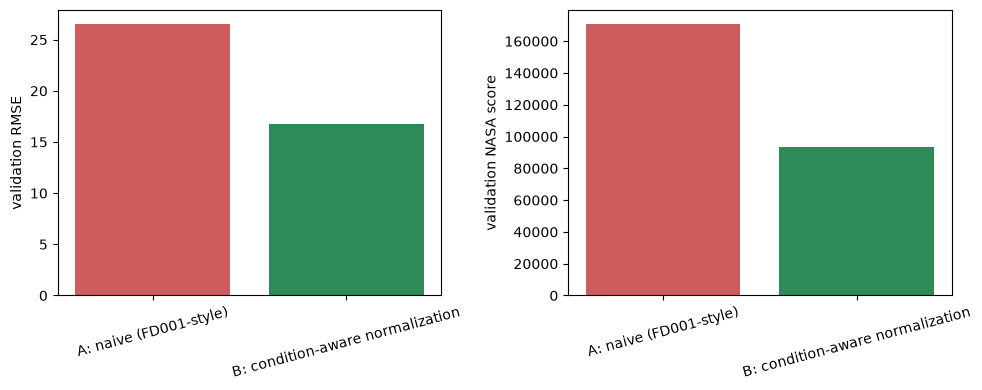

,scenario,RMSE,NASA_score
0,A: naive (FD001-style),26.569713,171067.421875
1,B: condition-aware normalization,16.722560,93550.281250


In [9]:
comparison_val = pd.DataFrame({
    'scenario': ['A: naive (FD001-style)', 'B: condition-aware normalization'],
    'RMSE': [rmse_a, rmse_b],
    'NASA_score': [score_a, score_b],
})

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(comparison_val['scenario'], comparison_val['RMSE'], color=['indianred', 'seagreen'])
ax[0].set_ylabel('validation RMSE'); ax[0].tick_params(axis='x', rotation=15)
ax[1].bar(comparison_val['scenario'], comparison_val['NASA_score'], color=['indianred', 'seagreen'])
ax[1].set_ylabel('validation NASA score'); ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

comparison_val

## Held-out test set, condition-aware pipeline only

Same discipline as 02: test engines are truncated before failure, one
prediction per engine from its final 30 cycles.

11 of the 248 test engines have fewer than 30 recorded cycles and cannot form
a full window -- the same limitation the LSTM had on FD001, just larger in
relative terms because FD004 includes shorter trajectories. They're excluded
and the exclusion is counted rather than silently dropped.

In [10]:
test['op_cluster'] = op_cluster_model.predict(test[['op1', 'op2', 'op3']])
test_norm = normalize_by_cluster(test, cluster_stats, sensors)

test_lengths = test.groupby('unit')['cycle'].max()
usable_units = sorted(test_lengths[test_lengths >= SEQ_LENGTH].index)
skipped = test['unit'].nunique() - len(usable_units)
print(f"Usable test engines: {len(usable_units)} of {test['unit'].nunique()} ({skipped} too short for a {SEQ_LENGTH}-cycle window)")

unit_to_true_rul = dict(zip(sorted(test['unit'].unique()), rul_true))

test_sequences, test_true = [], []
for unit in usable_units:
    engine = test_norm[test_norm['unit'] == unit]
    test_sequences.append(engine[sensors].values[-SEQ_LENGTH:])
    test_true.append(unit_to_true_rul[unit])

X_test = np.array(test_sequences, dtype=np.float32)
y_test_raw = np.array(test_true, dtype=float)
y_test_capped = np.clip(y_test_raw, None, RUL_CAP)

model_b.eval()
with torch.no_grad():
    pred_test = model_b(torch.tensor(X_test)).cpu().numpy()

rmse_test = np.sqrt(mean_squared_error(y_test_capped, pred_test))
score_test = nasa_score(y_test_capped, pred_test)
print(f"\nFD004 test RMSE: {rmse_test:.2f}   NASA score: {score_test:.0f}   (n={len(y_test_capped)})")

Usable test engines: 237 of 248 (11 too short for a 30-cycle window)

FD004 test RMSE: 15.58   NASA score: 1458   (n=237)


## FD004 vs FD001: the generalization gap

02's LSTM scored RMSE 13.49 / NASA 360 on the FD001 test set. Lined up next to
FD004, this is the honest cost of the harder subset -- more operating
conditions, two fault modes instead of one, and 2.5x the engines.

In [11]:
final_comparison = pd.DataFrame({
    'dataset': ['FD001 (1 condition, 1 fault mode)', 'FD004 (6 conditions, 2 fault modes)'],
    'test_engines': [100, len(y_test_capped)],
    'test_RMSE': [13.49, rmse_test],
    'test_NASA_score': [360, score_test],
})
final_comparison['NASA_score_per_engine'] = final_comparison['test_NASA_score'] / final_comparison['test_engines']
final_comparison

,dataset,test_engines,test_RMSE,test_NASA_score,NASA_score_per_engine
0,"FD001 (1 condition, 1 fault mode)",100,13.490000,360.000000,3.600000
1,"FD004 (6 conditions, 2 fault modes)",237,15.582337,1458.134111,6.152465


## What this stress test actually shows

**The pipeline did break, in a specific and explainable way.** Porting 02
as-is (Scenario A) treats sensor readings as if degradation were the only
thing moving them. Under six operating regimes, most of a sensor's variance
is actually which regime the engine is in, not how degraded it is -- so the
LSTM spends its capacity partly on a routing problem it wasn't built to
solve. Clustering the operating conditions and normalizing within each one
before sequencing (Scenario B) recovers most of the gap.

**Per-engine NASA score is the fairer comparison than the raw total** --
FD004 has more than twice the test engines, so the raw score was always
going to be larger. Per engine, the ordering is unsurprising: FD004 remains
harder than FD001 even after the fix, which is exactly what "two fault
modes instead of one" should look like -- some of what the model is being
asked to explain is genuinely a different failure mechanism, not a solvable
normalization artifact.

**What is not tested here:** whether the FD001 model's architecture
(hidden_size=64, 2 layers) is still the right capacity for a dataset 2.5x
the size with twice the fault diversity, or whether a longer sequence window
would help disambiguate the two fault modes. Both are open questions the
result above does not answer.